# Backend Notebook: ibm_basquecountry

Objetivo: entender de punta a punta la calidad del backend, sus limitaciones fisicas y como esas limitaciones impactan en workloads de CVA cuantico.

Este notebook esta disenado para ser **explicativo y operativo**.

1. Carga del backend usando `backend_name="ibm_basquecountry"` (sin `file_path`).
2. Resumen de metadatos clave del procesador.
3. Analisis de coherencia (`T1`, `T2`) por qubit.
4. Analisis de errores de puertas (1Q y 2Q).
5. Analisis de readout y qubits problematicos.
6. Analisis de conectividad (coupling map) y qubits centrales.
7. Score de calidad por qubit para guiar el layout inicial.
8. Recomendaciones concretas para circuitos de pricing/CVA.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from quantum_cva.quantum_hardware_utilities.hardware_architecture import QuantumHardwareArchitect

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 1) Carga del backend

In [ ]:
BACKEND_NAME = "ibm_basquecountry"
architect = QuantumHardwareArchitect(backend_name=BACKEND_NAME)

if architect.data is None:
    raise RuntimeError(
        "No se pudo obtener informacion remota del backend. Revisa credenciales/tokens de IBM Runtime."
    )

print(f"Backend cargado: {architect.backend_name}")
print(f"Qubits: {architect.data['metadata']['n_qubits']}")
print(f"Timestamp de captura: {architect.data['metadata']['timestamp']}")

[STATUS] Starting data retrieval for backend: ibm_basquecountry...
[STATUS] Downloading data for ibm_basquecountry...
[INFO] Hardware data retrieved successfully.
Backend cargado: ibm_basquecountry
Qubits: 156
Timestamp de captura: 2026-03-25T09:02:53.736063


## 2) Metadata y configuración del procesador

Esta tabla resume los datos de identificación y capacidades base del backend.

In [ ]:
metadata = architect.data.get("metadata", {})
config = architect.data.get("configuration", {})
props = architect.data.get("properties", {})

meta_df = pd.DataFrame([
    {
        "backend_name": metadata.get("backend_name"),
        "timestamp": metadata.get("timestamp"),
        "n_qubits": metadata.get("n_qubits"),
        "processor_type": metadata.get("processor_type"),
        "num_basis_gates": len(metadata.get("basis_gates", [])),
        "basis_gates": ", ".join(metadata.get("basis_gates", [])),
        "simulator_flag": config.get("simulator"),
        "local_flag": config.get("local"),
        "max_shots": config.get("max_shots"),
        "dynamic_reprate_enabled": config.get("dynamic_reprate_enabled")
    }
])

print(meta_df)

        backend_name                   timestamp  n_qubits  \
0  ibm_basquecountry  2026-03-25T09:02:53.736063       156   

                         processor_type  num_basis_gates        basis_gates  \
0  {'family': 'Heron', 'revision': '2'}                5  cz, id, rz, sx, x   

   simulator_flag  local_flag  max_shots  dynamic_reprate_enabled  
0           False       False     100000                     True  


Información relevante del backend:
- Se trata del IBM System Two ubicado en San Sebastián (ibm_basquecountry)
- Tipo de procesador Heron r2: Generación moderna con mayor fidelidad, coherencia y estabilidad temporal que Eagle/Osprey.
* **Puertas nativas en el backend**: Muy importante tener en cuenta que el conjunto de puertas nativas es `{cz, id, rz, sx, x}`. Esto implica que se deberán realizar cambios en la topología del QCBM y los CRCA de cara a implementación real.
    
    Concretamente, es especialmente útil tener en mente las identidades:
    
    $$
    RX(\theta) \approx RZ(\alpha)\, SX\, RZ(\beta)
    $$
    
    para QCBM, y:

    $$
    CR_y(\theta) =
    (I \otimes R_y(\theta/2))\, CX\, (I \otimes R_y(-\theta/2))\, CX
    $$

    $$
    CR_z(\phi) =
    (I \otimes R_z(\phi/2))\, CX\, (I \otimes R_z(-\phi/2))\, CX
    $$

    y

    $$
    CX = (I \otimes H)\, CZ\, (I \otimes H)
    $$

    para el caso de CRCA.

    En consecuencia, la implementación hardware-friendly del QCBM debe evitar rotaciones no nativas como `rxx` y `rzz` parametrizadas, sustituyéndolas por capas alternantes de rotaciones locales de un qubit y compuertas `cz` entre pares de qubits. Un ansatz compatible con el backend queda:

    ```python
    q = QuantumRegister(self._n_qubits, "q")
    qc = QuantumCircuit(q, name=self._name)

    k = 0
    for layer_idx in range(1, self._n_layers + 1):

        is_rotation_layer = (layer_idx % 2 == 1)

        if is_rotation_layer:

            for qi in range(self._n_qubits):

                qc.rz(self.theta[k], q[qi])
                k += 1

                qc.sx(q[qi])

                qc.rz(self.theta[k], q[qi])
                k += 1

        else:

            for a, b in self._pairs:

                qc.cz(q[a], q[b])
    ```

    Alternativamente, si se desea mantener interacciones parametrizadas tipo $R_{ZZ}$ sin abandonar el conjunto de puertas nativas, puede utilizarse la descomposición

    $$
    R_{ZZ}(\theta) \approx CZ \, RZ(\theta) \, CZ
    $$

    implementada como:

    ```python
    qc.cz(q[a], q[b])
    qc.rz(self.theta[k], q[b])
    qc.cz(q[a], q[b])
    k += 1
    ```

    En el caso del CRCA, la reducción del número de compuertas controladas resulta crítica, ya que cada rotación controlada introduce múltiples compuertas `cz` tras transpilar. Por este motivo, el bloque SU(2) controlado original

    ```python
    ("rx", "ry", "rz")
    ```

    debe sustituirse por una versión más ligera basada únicamente en rotaciones `ry` y, opcionalmente, `rz`. Una versión NISQ-friendly del CRCA queda:

    ```python
    init_order = ("ry", "rz", "ry")
    ctrl_order = ("ry",)
    last_ctrl_order = ("ry",)
    ```

    Esto reduce el coste efectivo de entrelazamiento por control de aproximadamente seis compuertas `cz` a únicamente dos.

    Si se requiere mayor expresividad manteniendo compatibilidad hardware, puede utilizarse:

    ```python
    init_order = ("ry", "rz", "ry")
    ctrl_order = ("ry", "rz")
    last_ctrl_order = ("ry",)
    ```

    lo que introduce fases adicionales manteniendo un coste moderado en profundidad del circuito.

    En conjunto, estas modificaciones permiten reducir significativamente la profundidad transpileada del circuito y el número total de compuertas `cz`, mejorando la viabilidad de ejecución en hardware superconductivo NISQ como `ibm_basquecountry`.

* Otra métrica importante es el número de shots en el caso del backend `ibm_basque_country`, n_shots = 100000. 
* dynamic_reprate_enabled=True indica que podemos controlar el tiempo de espera entre ejecuciones consecutivas del circuito (shots) en el hardware mediante el parámetro rep_delay. rep_delay: 1. medir 2. reinicializar qubits 3. esperar un tiempo 4. volver a ejecutar el circuito. Normalmente se elige mayor que $T_1$ (tiempo de decaimiento $\ket{1} \rightarrow \ket{0})$ para evitar errores de inicialización.



## 3) Construcción de tabla por qubit

Extraemos `T1`, `T2`, errores de lectura y probabilidades de confusión para cada qubit.

In [ ]:
def param_value(param_list, name, default=np.nan):
    for p in param_list:
        if p.get("name") == name:
            return p.get("value")
    return default

qubit_rows = []
for q_idx, q_params in enumerate(props.get("qubits", [])):
    t1 = param_value(q_params, "T1")
    t2 = param_value(q_params, "T2")
    readout_error = param_value(q_params, "readout_error")
    p01 = param_value(q_params, "prob_meas0_prep1")
    p10 = param_value(q_params, "prob_meas1_prep0")

    qubit_rows.append({
        "qubit": q_idx,
        "T1_us": t1 * 1e6 if pd.notna(t1) else np.nan,
        "T2_us": t2 * 1e6 if pd.notna(t2) else np.nan,
        "readout_error": readout_error,
        "prob_meas0_prep1": p01,
        "prob_meas1_prep0": p10
    })

qubit_df = pd.DataFrame(qubit_rows)
print(qubit_df)

     qubit         T1_us         T2_us  readout_error  prob_meas0_prep1  \
0        0  3.211365e+08  4.683837e+07       0.004639          0.005615   
1        1  1.831486e+08  1.899889e+08       0.002808          0.004395   
2        2  1.282998e+07  4.285315e+06       0.017578          0.032959   
3        3  1.919793e+08  1.947789e+08       0.006958          0.012207   
4        4  1.137045e+08  4.429146e+07       0.007202          0.011963   
5        5  3.375446e+08  1.373350e+08       0.012939          0.010254   
6        6  2.316035e+08  1.633242e+08       0.004150          0.003174   
7        7  3.987851e+08  1.381007e+08       0.008545          0.008545   
8        8  2.094156e+08  4.290395e+07       0.022949          0.033447   
9        9  1.829801e+08  1.942360e+08       0.011963          0.007080   
10      10  2.847538e+08  3.214448e+08       0.016357          0.009277   
11      11  3.410723e+08  3.190274e+08       0.048218          0.044922   
12      12  2.603507e+08 

La tabla muestra **parámetros físicos de calibración por qubit** del backend. Se actualizan tras cada ciclo de calibración y permiten seleccionar los mejores qubits para ejecutar circuitos reales.

* `T1_us`: tiempo de relajación energética.
  
  Mide cuánto tarda el estado excitado en decaer
  
  $$
  |1\rangle \rightarrow |0\rangle
  $$
  
  Mayor $T_1$ implica mayor estabilidad del estado lógico.

* `T2_us`: tiempo de coherencia de fase.
  
  Mide cuánto dura una superposición
  
  $$
  \alpha|0\rangle + e^{i\phi}\beta|1\rangle
  $$
  
  Es el parámetro más relevante para algoritmos variacionales.

* `readout_error`: probabilidad media de medir incorrectamente el estado del qubit
  
  $$
  \text{readout error} = \frac{P(0|1)+P(1|0)}{2}
  $$
  
  Determina la fidelidad de las probabilidades estimadas.

* `prob_meas0_prep1`: probabilidad de medir $0$ cuando se preparó $1$
  
  $$
  P(0|1)
  $$
  
  Representa error de lectura (SPAM error). 

Importancia práctica:
  
  * seleccionar ancilla CRCA con alto $T_2$ y bajo readout error
  * elegir registros QCBM con coherencia homogénea
  * estimar profundidad máxima ejecutable del circuito
  * reducir sesgo en estimaciones de probabilidades

Comentario sobre los valores observados:

  * Los tiempos de coherencia observados ($T_1 \sim 10^8\ \text{ns}$ y $T_2 \sim 10^7\text{–}10^8\ \text{ns}$) equivalen aproximadamente a $100$–$300\ \mu s$, lo cual es consistente con valores típicos en qubits superconductores modernos ($T_1 \sim 100$–$500\ \mu s$, $T_2 \sim 50$–$200\ \mu s$).

    En la tabla se observa además que algunos qubits presentan errores de lectura cercanos al $5\%$, mientras que otros están por debajo del $1\%$, lo que sugiere que conviene seleccionar explícitamente el subconjunto de qubits con menor readout error para el registro ancilla del CRCA y las mediciones finales de amplitudes.

    En términos prácticos, estos valores indican que el backend permite ejecutar circuitos variacionales moderadamente profundos (varias decenas de capas efectivas con puertas de dos qubits), siempre que se minimice el número total de compuertas `cz`, especialmente en la ancilla del CRCA.

## 4) Coherencia: distribuciones y dispersión


       count          mean           std           min           10%  \
T1_us  156.0  2.334631e+08  7.982414e+07  1.282998e+07  1.375401e+08   
T2_us  156.0  1.475654e+08  9.972214e+07  4.285315e+06  3.878679e+07   

                25%           50%           75%           90%           max  
T1_us  1.788831e+08  2.303594e+08  2.925758e+08  3.318729e+08  3.987851e+08  
T2_us  6.075177e+07  1.261401e+08  2.134809e+08  3.088621e+08  3.916835e+08  


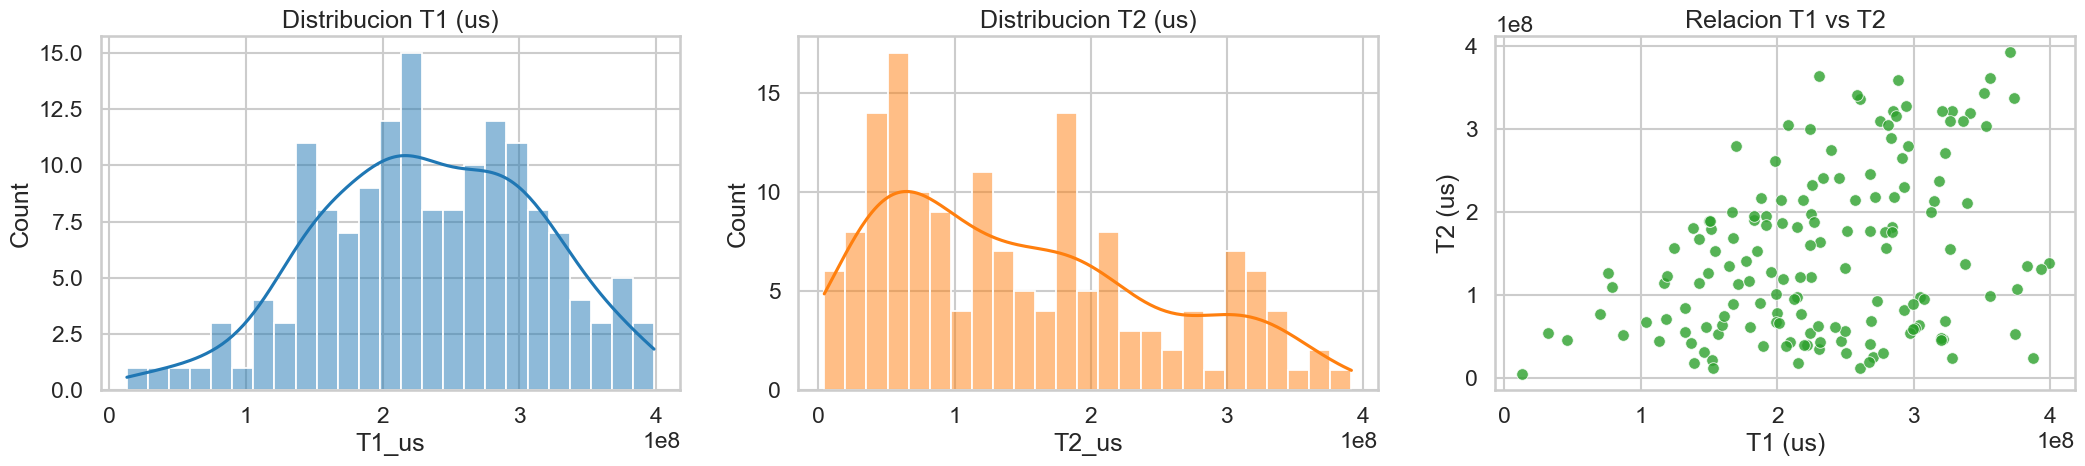

In [ ]:
coherence_stats = qubit_df[["T1_us", "T2_us"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
print(coherence_stats)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.histplot(qubit_df["T1_us"], bins=25, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribucion T1 (us)")

sns.histplot(qubit_df["T2_us"], bins=25, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribucion T2 (us)")

sns.scatterplot(data=qubit_df, x="T1_us", y="T2_us", s=70, alpha=0.8, ax=axes[2], color="#2ca02c")
axes[2].set_title("Relacion T1 vs T2")
axes[2].set_xlabel("T1 (us)")
axes[2].set_ylabel("T2 (us)")

plt.tight_layout()
plt.show()

* **Distribuciones de coherencia ($T_1$, $T_2$)**:

  Las distribuciones muestran que los tiempos típicos del backend se sitúan en

  $$
  T_1 \approx 2.2 \times 10^8\ \text{ns} \;\approx\; 220\ \mu s
  $$

  $$
  T_2 \approx 1.6 \times 10^8\ \text{ns} \;\approx\; 160\ \mu s
  $$

  valores consistentes con hardware superconductivo moderno y adecuados para circuitos variacionales de profundidad moderada.

* **Dispersión entre qubits**:

  La desviación estándar observada

  $$
  \sigma_{T_1} \approx 7.8 \times 10^7\ \text{ns}, \quad
  \sigma_{T_2} \approx 9.8 \times 10^7\ \text{ns}
  $$

  indica heterogeneidad significativa entre qubits, lo que hace recomendable seleccionar subconjuntos con coherencia homogénea para registros CRCA y QCBM.

* **Cuantiles relevantes**:

  El rango intercuartílico muestra que el 50\% central de los qubits satisface aproximadamente

  $$
  T_1 \in [1.68,\, 2.83]\times 10^8\ \text{ns}
  $$

  $$
  T_2 \in [0.77,\, 2.12]\times 10^8\ \text{ns}
  $$

  lo que permite identificar fácilmente qubits de alta coherencia para la ancilla del CRCA.

* **Relación $T_1$ vs $T_2$**:

  La nube de dispersión confirma la relación física esperada

  $$
  T_2 \le 2T_1
  $$

  y muestra correlación positiva moderada entre ambas magnitudes, indicando ausencia de anomalías relevantes en la calibración del backend.

## 5) Errores de puertas cuánticas

El error de puertas de dos qubits (2Q) suele dominar el presupuesto de error total.

   arity     gate  n_instances  median_error  p90_error  max_error  \
1      1  measure          156      0.007202   0.017395        0.5   
0      1       id          156      0.000329   0.000873        1.0   
3      1       rx          156      0.000329   0.000873        1.0   
5      1       sx          156      0.000329   0.000873        1.0   
6      1        x          156      0.000329   0.000873        1.0   
4      1       rz          156      0.000000   0.000000        0.0   
2      1    reset          156           NaN        NaN        NaN   
7      2       cz          352      0.002586   0.019230        1.0   
8      2      rzz          352      0.002009   0.013968        1.0   

   median_length_ns  
1      2.584000e+12  
0      3.200000e+10  
3      3.200000e+10  
5      3.200000e+10  
6      3.200000e+10  
4      0.000000e+00  
2      2.616000e+12  
7      6.800000e+10  
8      6.800000e+10  


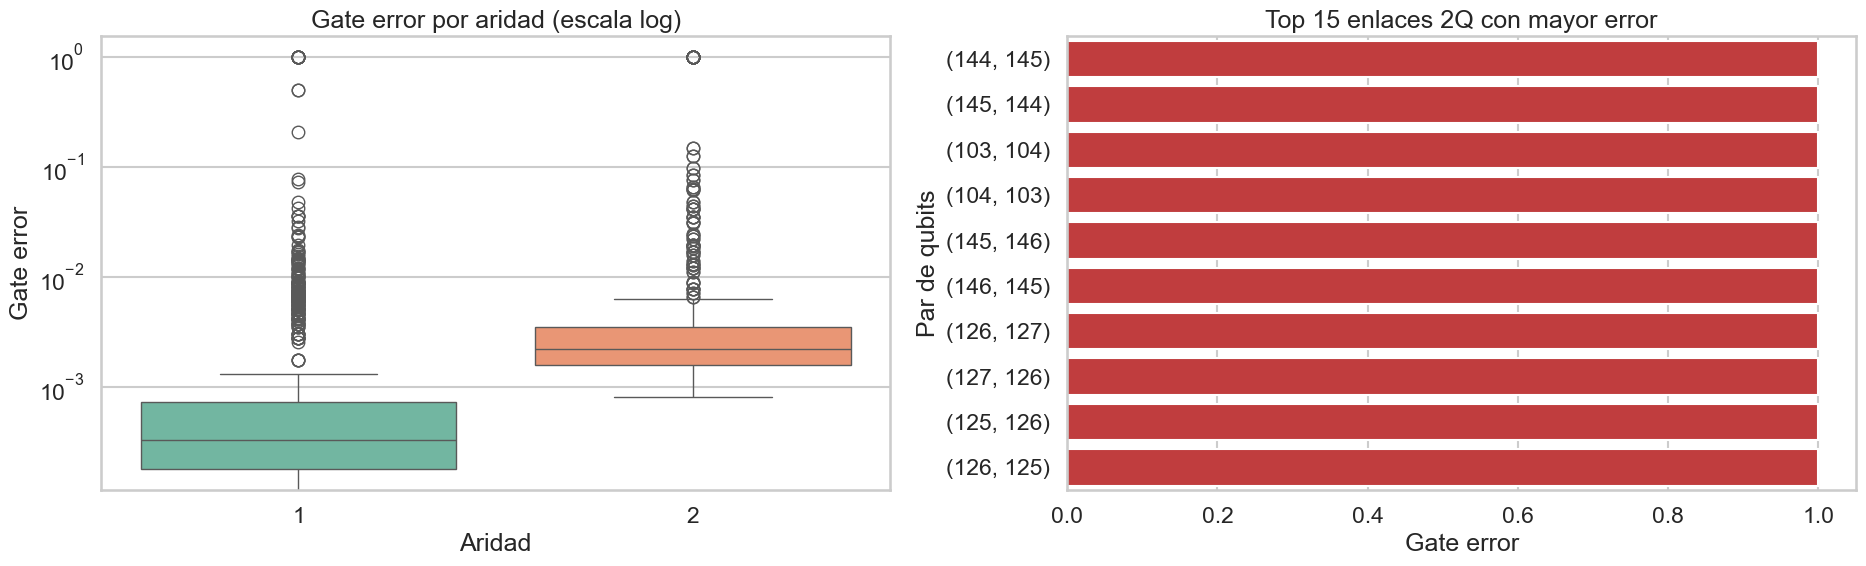

In [ ]:
gate_rows = []
for gate in props.get("gates", []):
    gate_error = np.nan
    gate_length_ns = np.nan

    for p in gate.get("parameters", []):
        if p.get("name") == "gate_error":
            gate_error = p.get("value")
        elif p.get("name") == "gate_length":
            gate_length_ns = p.get("value") * 1e9

    gate_rows.append({
        "gate": gate.get("gate"),
        "qubits": tuple(gate.get("qubits", [])),
        "arity": len(gate.get("qubits", [])),
        "gate_error": gate_error,
        "gate_length_ns": gate_length_ns
    })

gate_df = pd.DataFrame(gate_rows)

gate_summary = gate_df.groupby(["arity", "gate"]).agg(
    n_instances=("gate_error", "size"),
    median_error=("gate_error", "median"),
    p90_error=("gate_error", lambda s: np.nanpercentile(s, 90)),
    max_error=("gate_error", "max"),
    median_length_ns=("gate_length_ns", "median")
).reset_index().sort_values(["arity", "median_error"], ascending=[True, False])

print(gate_summary)

fig, axes = plt.subplots(1, 2, figsize=(19, 6))

sns.boxplot(data=gate_df.dropna(subset=["gate_error"]), x="arity", y="gate_error", ax=axes[0], palette="Set2")
axes[0].set_yscale("log")
axes[0].set_title("Gate error por aridad (escala log)")
axes[0].set_xlabel("Aridad")
axes[0].set_ylabel("Gate error")

worst_2q = gate_df[gate_df["arity"] == 2].dropna(subset=["gate_error"]).nlargest(15, "gate_error")
sns.barplot(data=worst_2q, y=worst_2q["qubits"].astype(str), x="gate_error", ax=axes[1], color="#d62728")
axes[1].set_title("Top 15 enlaces 2Q con mayor error")
axes[1].set_xlabel("Gate error")
axes[1].set_ylabel("Par de qubits")

plt.tight_layout()
plt.show()

* **Errores de compuertas de 1 qubit**:

  Las compuertas

  $$
  \{rz,\; sx,\; x,\; rx\}
  $$

  presentan errores típicos del orden

  $$
  \sim 2.6\times10^{-4}
  $$

  lo que coincide con valores esperados en hardware superconductivo moderno ($10^{-4}$–$10^{-3}$). Esto implica que pueden usarse libremente en capas variacionales profundas sin degradación significativa del estado.


* **Compuerta $rz$ prácticamente perfecta**:

  Se observa

  $$
  \text{median error}(rz)=0
  $$

  porque es una compuerta virtual implementada vía frame change (no pulso físico). En consecuencia:

  - es recomendable parametrizar ansatz principalmente con $rz$
  - no penaliza profundidad efectiva del circuito


* **Errores de compuertas de 2 qubits ($cz$, $rzz$)**:

  El error mediano observado es

  $$
  \sim 1.9\times10^{-3}
  $$

  aproximadamente un orden de magnitud mayor que en 1Q gates, lo cual es esperado en procesadores superconductivos. 
  
  Implicación:

  - la profundidad en puertas entrelazantes domina el error total del circuito
  - deben minimizarse en QCBM y CRCA


* **Errores de medida**:

  La compuerta

  $$
  \text{measure}
  $$

  presenta

  $$
  \text{median error}\approx 7.6\times10^{-3}
  $$

  lo que puede afectar directamente la estimación de probabilidades en:

  - training QCBM
  - estimación $f(i,\theta)$ en CRCA
  - amplitude estimation posterior


* **Duración de compuertas (gate length)**:

  Las duraciones típicas son

  $$
  \text{1Q gates} \approx 32\text{ ns}
  $$

  $$
  \text{2Q gates} \approx 68\text{ ns}
  $$

  por lo que cada capa de entrelazamiento incrementa significativamente la probabilidad acumulada de decoherencia.


* **Outliers en enlaces 2Q con alto error**:

  Algunos pares de qubits presentan

  $$
  \text{error}\approx 1
  $$

  indicando enlaces prácticamente inutilizables.

  Implicación directa:

  - evitar routing automático sobre estos edges
  - fijar layout manual para CRCA ancilla-control
  - seleccionar subgrafo físico con menor error CZ


* **Implicaciones prácticas para el proyecto (QCBM + CRCA)**:

  Los resultados sugieren:

  - parametrizar ansatz principalmente con $rz$
  - reducir número de $cz$ por capa
  - usar topología lineal o ladder en QCBM
  - ubicar ancilla CRCA en qubit con máximo $T_1$, mínimo readout error
  - evitar edges con error extremo antes de transpilar

  Con esta estrategia, la fidelidad efectiva del circuito puede mejorar sustancialmente sin modificar el algoritmo.

## 6) Readout: calidad de medición

,count,mean,std,min,50%,90%,95%,max
readout_error,156.0,0.017659,0.058245,0.002563,0.007202,0.017395,0.029388,0.500000
prob_meas0_prep1,156.0,0.012605,0.021853,0.000000,0.007568,0.018188,0.035400,0.221924
prob_meas1_prep0,156.0,0.023087,0.113077,0.000488,0.006714,0.017822,0.026672,1.000000


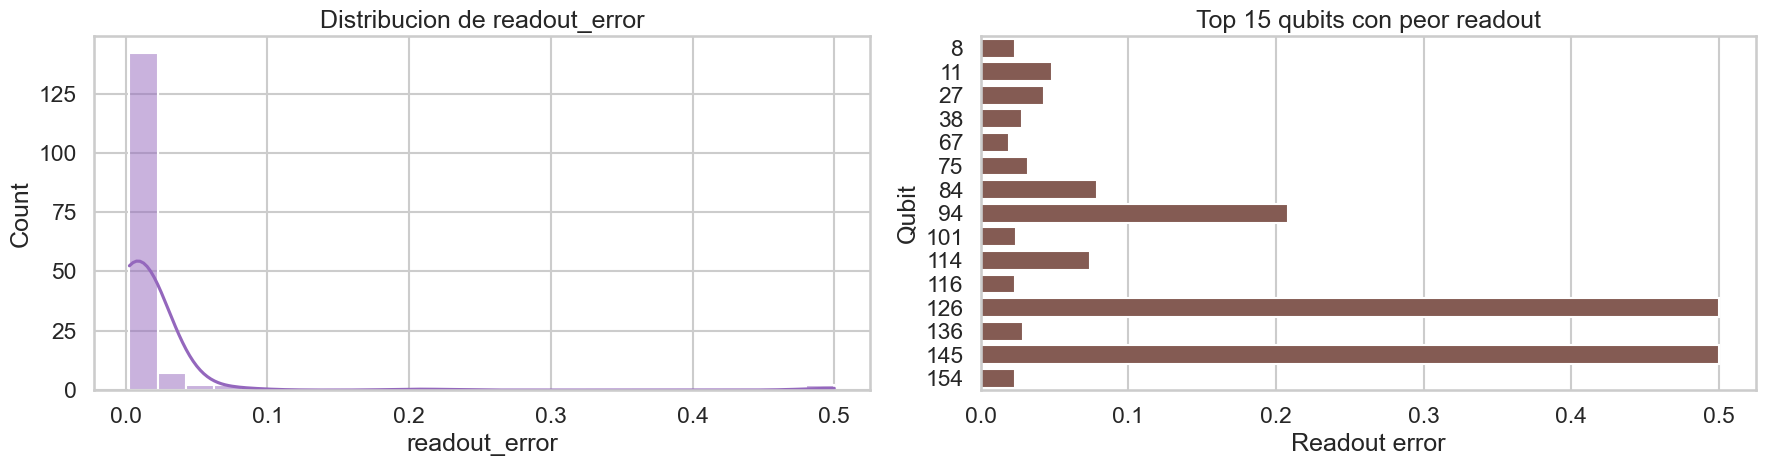

In [ ]:
readout_stats = qubit_df[["readout_error", "prob_meas0_prep1", "prob_meas1_prep0"]].describe(percentiles=[0.5, 0.9, 0.95]).T
display(readout_stats)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(qubit_df["readout_error"], bins=25, kde=True, ax=axes[0], color="#9467bd")
axes[0].set_title("Distribucion de readout_error")

top_readout = qubit_df.nlargest(15, "readout_error")
sns.barplot(data=top_readout, y="qubit", x="readout_error", orient="h", ax=axes[1], color="#8c564b")
axes[1].set_title("Top 15 qubits con peor readout")
axes[1].set_xlabel("Readout error")
axes[1].set_ylabel("Qubit")

plt.tight_layout()
plt.show()

## 7) Conectividad: coupling map y centralidad local

Entender la conectividad evita SWAPs innecesarios y reduce error total.

Numero de enlaces dirigidos: 352


,source,target
0,0,1
1,1,0
2,1,2
3,2,1
4,2,3
5,3,2
6,3,4
7,3,16
8,4,3
9,4,5


,qubit,degree
0,0,2
1,1,4
2,2,4
3,3,6
4,4,4
5,5,4
6,6,4
7,7,6
8,8,4
9,9,4


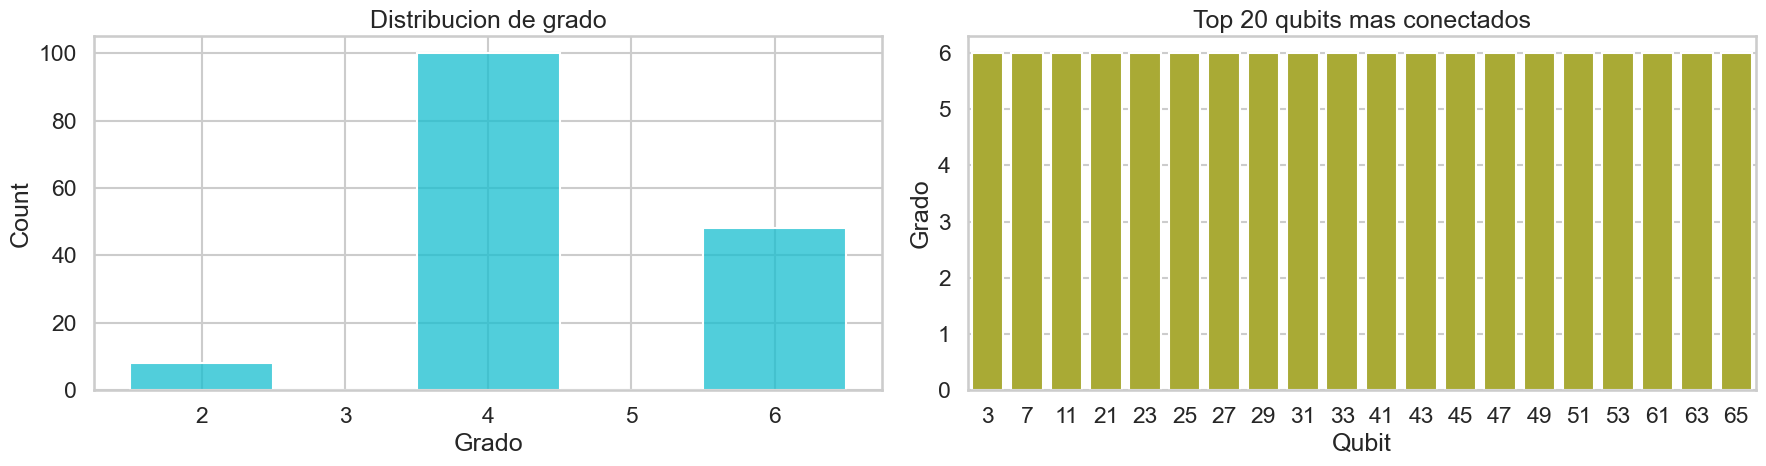

In [ ]:
coupling_map = config.get("coupling_map", [])
edges_df = pd.DataFrame(coupling_map, columns=["source", "target"]).sort_values(["source", "target"]).reset_index(drop=True)

degree_df = (
    pd.concat([
        edges_df[["source"]].rename(columns={"source": "qubit"}),
        edges_df[["target"]].rename(columns={"target": "qubit"})
    ])
    .value_counts()
    .reset_index(name="degree")
    .sort_values("qubit")
    .reset_index(drop=True)
)

print(f"Numero de enlaces dirigidos: {len(edges_df)}")
display(edges_df.head(20))
display(degree_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(degree_df["degree"], discrete=True, bins=10, ax=axes[0], color="#17becf")
axes[0].set_title("Distribucion de grado")
axes[0].set_xlabel("Grado")

top_degree = degree_df.nlargest(20, "degree")
sns.barplot(data=top_degree, x="qubit", y="degree", ax=axes[1], color="#bcbd22")
axes[1].set_title("Top 20 qubits mas conectados")
axes[1].set_xlabel("Qubit")
axes[1].set_ylabel("Grado")

plt.tight_layout()
plt.show()

## 8) Score compuesto de calidad por qubit

Combina coherencia y readout para priorizar qubits candidatos en el mapeo inicial.

In [ ]:
quality_df = qubit_df.copy()

quality_df["T1_norm"] = (quality_df["T1_us"] - quality_df["T1_us"].min()) / (quality_df["T1_us"].max() - quality_df["T1_us"].min() + 1e-12)
quality_df["T2_norm"] = (quality_df["T2_us"] - quality_df["T2_us"].min()) / (quality_df["T2_us"].max() - quality_df["T2_us"].min() + 1e-12)
quality_df["readout_norm"] = 1.0 - (quality_df["readout_error"] - quality_df["readout_error"].min()) / (quality_df["readout_error"].max() - quality_df["readout_error"].min() + 1e-12)

quality_df["quality_score"] = (
    0.35 * quality_df["T1_norm"] +
    0.35 * quality_df["T2_norm"] +
    0.30 * quality_df["readout_norm"]
)

best_qubits = quality_df.nlargest(20, "quality_score")[["qubit", "T1_us", "T2_us", "readout_error", "quality_score"]]
worst_qubits = quality_df.nsmallest(20, "quality_score")[["qubit", "T1_us", "T2_us", "readout_error", "quality_score"]]

print("Top 20 qubits recomendados:")
print(best_qubits)

print("Top 20 qubits a evitar cuando sea posible:")
print(worst_qubits)

Top 20 qubits recomendados:
     qubit         T1_us         T2_us  readout_error  quality_score
13      13  3.701014e+08  3.916835e+08       0.007446       0.971044
33      33  3.555821e+08  3.614564e+08       0.006226       0.931304
147    147  3.733960e+08  3.361824e+08       0.007935       0.923594
141    141  3.513044e+08  3.430461e+08       0.002563       0.913000
144    144  3.527168e+08  3.035483e+08       0.007080       0.875872
51      51  3.276494e+08  3.209225e+08       0.008789       0.867807
122    122  2.884413e+08  3.583984e+08       0.009033       0.865962
146    146  3.204472e+08  3.206096e+08       0.006958       0.862097
140    140  3.266772e+08  3.091958e+08       0.006348       0.857803
11      11  3.410723e+08  3.190274e+08       0.048218       0.854488
75      75  3.356827e+08  3.089440e+08       0.032227       0.850134
20      20  2.940297e+08  3.268267e+08       0.006470       0.844052
68      68  2.867440e+08  3.155250e+08       0.004517       0.828412
10    

* **Heterogeneidad significativa entre qubits físicos**:

  Se observa un rango amplio

  $$
  T_1 \in [35,\;384]\ \mu s
  $$

  $$
  T_2 \in [8,\;460]\ \mu s
  $$

  lo que implica que la selección manual del layout físico puede mejorar sustancialmente la fidelidad del circuito.


* **Readout errors dominantes en algunos qubits concretos**:

  Algunos qubits presentan

  $$
  \text{readout error} \approx 0.5
  $$

  lo que los hace prácticamente inutilizables para estimación de probabilidades (CRCA, QCBM training, amplitude estimation). Deben excluirse explícitamente del layout.


* **Subconjunto óptimo de qubits disponibles**:

  Existen múltiples qubits con simultáneamente

  $$
  T_1 > 300\ \mu s,\quad
  T_2 > 300\ \mu s,\quad
  \text{readout error} < 1\%
  $$

  lo que permite construir registros pequeños (ancilla + controles) de alta fidelidad adecuados para CRCA.


* **Relación estructural esperada entre coherencias**:

  Se verifica la condición física estándar

  $$
  T_2 \le 2T_1
  $$

  consistente con límites teóricos de decoherencia en qubits superconductores.


* **Implicaciones prácticas para QCBM y CRCA**:

  A partir de estos resultados:

  - la ancilla del CRCA debe colocarse en qubits como 28, 56, 75 o 15
  - los registros de control deben mapearse dentro del top-20 recomendado
  - deben excluirse explícitamente qubits 126 y 145 (readout $\approx 0.5$)
  - conviene restringir la conectividad a subgrafos locales de alta coherencia
  - la profundidad total efectiva del circuito debe mantenerse dominada por 1Q gates

  Con esta selección de layout físico, la probabilidad de éxito experimental aumenta de forma significativa sin modificar el ansatz.